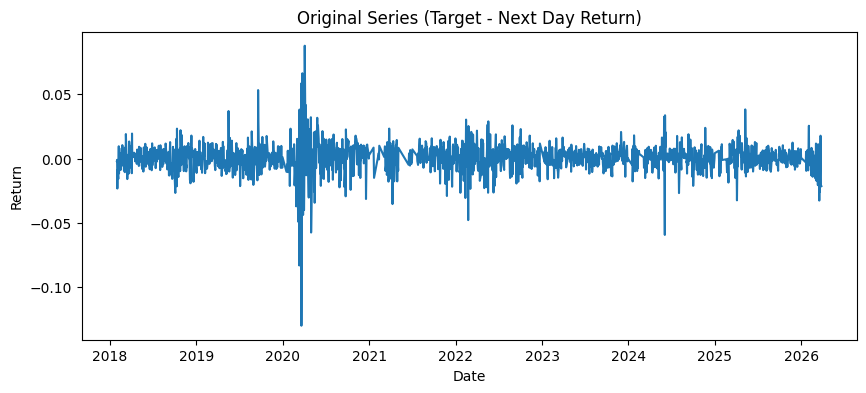


ADF Test for Original Series
ADF Statistic: -11.453084497316091
p-value: 5.794016579060245e-21
Critical Values: {'1%': np.float64(-3.4339167027591952), '5%': np.float64(-2.8631154999882167), '10%': np.float64(-2.5676087418063327)}


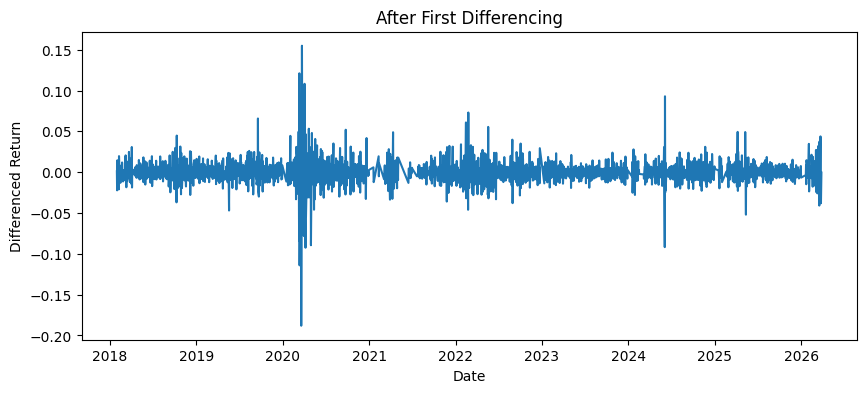


ADF Test for After 1st Differencing
ADF Statistic: -14.193814464239882
p-value: 1.8372170282411865e-26
Critical Values: {'1%': np.float64(-3.4339441475744668), '5%': np.float64(-2.8631276157416945), '10%': np.float64(-2.5676151930364455)}


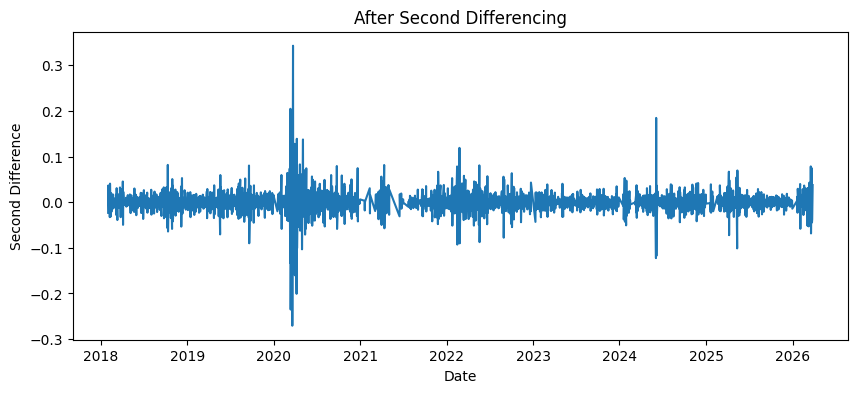


ADF Test for After 2nd Differencing
ADF Statistic: -18.708662115121548
p-value: 2.0352260028442436e-30
Critical Values: {'1%': np.float64(-3.4339461240890983), '5%': np.float64(-2.8631284882870625), '10%': np.float64(-2.5676156576381293)}


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("nifty_final_dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Use your forecasting target
y = df["target"]

# =========================
# FUNCTION: ADF TEST
# =========================
def adf_test(series, name="Series"):
    result = adfuller(series)

    print(f"\nADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])

# =========================
# ORIGINAL SERIES
# =========================
plt.figure(figsize=(10,4))
plt.plot(df["date"], y)
plt.title("Original Series (Target - Next Day Return)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

adf_test(y, "Original Series")

# =========================
# FIRST DIFFERENCING
# =========================
y_diff = y.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(df["date"].iloc[1:], y_diff)
plt.title("After First Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Return")
plt.show()

adf_test(y_diff, "After 1st Differencing")

# =========================
# OPTIONAL: SECOND DIFFERENCING
# =========================
y_diff2 = y_diff.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(df["date"].iloc[2:], y_diff2)
plt.title("After Second Differencing")
plt.xlabel("Date")
plt.ylabel("Second Difference")
plt.show()

adf_test(y_diff2, "After 2nd Differencing")

<Figure size 1000x400 with 0 Axes>

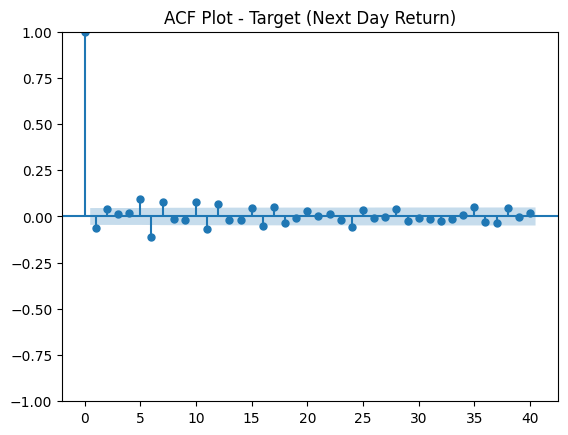

<Figure size 1000x400 with 0 Axes>

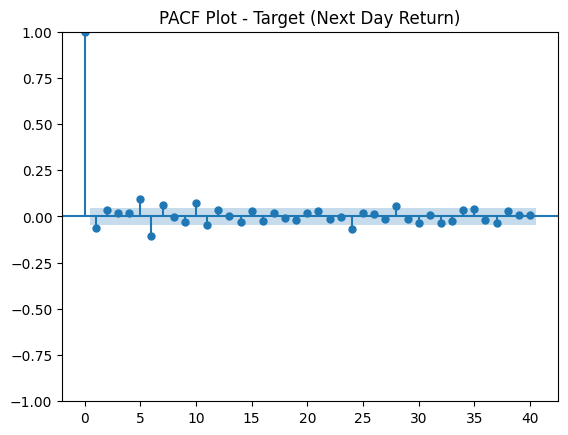

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# LOAD DATA
df = pd.read_csv("nifty_final_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# SELECT SERIES
series = df["target"]

# ACF PLOT
plt.figure(figsize=(10,4))
plot_acf(series, lags=40)
plt.title("ACF Plot - Target (Next Day Return)")
plt.show()

# PACF PLOT
plt.figure(figsize=(10,4))
plot_pacf(series, lags=40, method='ywm')
plt.title("PACF Plot - Target (Next Day Return)")
plt.show()